In [2]:
import os
#use the os module for interacting with the operating system
for dirname,_,filename in os.walk('/kaggle/input'):
#os.walk('/kaggle/input') generates dirpath,dirname and filename
#here use _ ignore dirname list since it's unused here
    for filename in filenames:
        print(os.path.join(dirname,filename))
#construct the full absolute path by combining the dirname and filename

In [3]:
import numpy as np #foundational package for numerical computing
import pandas as pd #library for data manipulation and analysis
import matplotlib as mpl #create static,animated and interactive visualization in python
import matplotlib.pyplot as plt #offer matlab like interface for quick plotting
import seaborn as sns #statistical visualization library
import warnings #mamage warning messages during execution

In [7]:
from sklearn.model_selection import train_test_split #splits datasets into training and testing subsets for model validation
from sklearn.model_selection import cross_val_predict #performs cross-validation to generate out-of-fold predictions across multiple data splits
from sklearn import metrics #general namespace for various evaluation functions
from sklearn.metrics import confusion_matrix #table summarizing prediction errors with rows as actual classes and columns as predcited classes
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc #area under curves like ROC or precision-recall, quantifying model discriminative power.
from sklearn.linear_model import LogisticRegression #import linear model for binary or multiclass classification
from sklearn.naive_bayes import GaussianNB #probabilistic classifier assuming Gaussian distributed features
from sklearn.neighbors import KNeighborsClassifier #non-parametric algorithm classifying based on majority vote of k nearest training samples in feature space.
from sklearn.svm import SVC #finds the optimal hyperplane maximizing margin between classes
from sklearn.tree import DecisionTreeClassifier #tree-based model that recursively splits data on feature thresholds to minimize impurity
from sklearn.ensemble import RandomForestClassifier #ensemble of decision trees using bagging and random feature selection

In [9]:
pd.plotting.register_matplotlib_converters() #registers pandas data type converters with matplotlib to properly handle datetime and categorical data in plots
%matplotlib inline #enables inline rendering of matplotlib plots 
plt.style.use('seaborn-v0_8-whitegrid')  #applies a clean, white background with grid lines style from the seaborn library
pd.set_option('display.max_columns', 500) #configures pandas to show up to 500 columns when printing DataFrames
warnings.filterwarnings("ignore") #suppresses all warning messages from libraries like pandas and sklearn

In [11]:
data = pd.read_csv(r'C:\Users\adas0\Downloads\Bank_Personal_Loan_Modelling.csv')
#reads the specified CSV file from the local Downloads folder into a pandas DataFrame named data using a raw string (r'...')
data.head(3) #display the first 3 rows of the DataFrame

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0


In [12]:
# let's explore the shape of the data. 
data.shape

(5000, 14)

In [13]:
# Let's Check if the data contains any missing or NaN values.
data.isnull().any()

ID                    False
Age                   False
Experience            False
Income                False
ZIP Code              False
Family                False
CCAvg                 False
Education             False
Mortgage              False
Personal Loan         False
Securities Account    False
CD Account            False
Online                False
CreditCard            False
dtype: bool

In [14]:
data.info() #displays a concise summary of the DataFrame structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [15]:
data.drop(['ID', 'ZIP Code'], axis = 1, inplace = True) #permanently removes the 'ID' and 'ZIP Code' columns from the data DataFrame.

In [16]:
data.isnull().sum() #detects and counts missing values across all columns in the DataFrame

Age                   0
Experience            0
Income                0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [17]:
# Dividing the columns in the dataset in to numeric and categorical attributes.
cols = set(data.columns)
cols_numeric = set(['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage'])
cols_categorical = list(cols - cols_numeric)
cols_categorical

['CD Account',
 'Education',
 'Family',
 'CreditCard',
 'Securities Account',
 'Online',
 'Personal Loan']

In [18]:
for x in cols_categorical:
    data[x] = data[x].astype('category')
data.info() #categorical columns to pandas' efficient category data type 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 5000 non-null   int64   
 1   Experience          5000 non-null   int64   
 2   Income              5000 non-null   int64   
 3   Family              5000 non-null   category
 4   CCAvg               5000 non-null   float64 
 5   Education           5000 non-null   category
 6   Mortgage            5000 non-null   int64   
 7   Personal Loan       5000 non-null   category
 8   Securities Account  5000 non-null   category
 9   CD Account          5000 non-null   category
 10  Online              5000 non-null   category
 11  CreditCard          5000 non-null   category
dtypes: category(7), float64(1), int64(4)
memory usage: 230.6 KB


In [19]:
data.describe().transpose() #comprehensive descriptive statistics for numerical columns and transposes the output

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0


In [20]:
data_num = data.select_dtypes(include='number')
data_cat = data.select_dtypes(include='category')
print(f'Numerical Attributes: {list(data_num.columns)}')
print(f'Categorical Attributes: {list(data_cat.columns)}') #numerical and categorical columns into distinct DataFrames and prints their column lists for analysis

Numerical Attributes: ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']
Categorical Attributes: ['Family', 'Education', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


In [21]:
# Let's construct a function that shows the summary and density distribution of a numerical attribute:
def summary(x): #Defines a reusable function taking single column name x as input parameter.
    x_min = data[x].min()
    x_max = data[x].max()
    Q1 = data[x].quantile(0.25)
    Q2 = data[x].quantile(0.50)
    Q3 = data[x].quantile(0.75)
#Calculates core 5-point summary statistics: minimum, maximum, and quartiles (25th, 50th/median, 75th percentiles) for column x.
    print(f'5 Point Summary of {x.capitalize()} Attribute:\n' #Prints formatted 5-point summary with capitalized column name and aligned statistics display
          f'{x.capitalize()}(min) : {x_min}\n'
          f'Q1                    : {Q1}\n'
          f'Q2(Median)            : {Q2}\n'
          f'Q3                    : {Q3}\n'
          f'{x.capitalize()}(max) : {x_max}')
    fig = plt.figure(figsize=(16, 10))
    plt.subplots_adjust(hspace = 0.6)
    sns.set_palette('pastel')
#Creates large figure (16x10 inches), adjusts subplot vertical spacing, sets pastel color palette for seaborn plots.
    plt.subplot(221)
    ax1 = sns.distplot(data[x], color = 'r')
    plt.title(f'{x.capitalize()} Density Distribution')
#histogram + kernel density estimate (KDE) in red for density distribution.
    plt.subplot(222)
    ax2 = sns.violinplot(x = data[x], palette = 'Accent', split = True)
    plt.title(f'{x.capitalize()} Violinplot')
# Violin plot showing density distribution + quartiles with split=True for mirrored view using Accent colors.
    plt.subplot(223)
    ax2 = sns.boxplot(x=data[x], palette = 'cool', width=0.7, linewidth=0.6)
    plt.title(f'{x.capitalize()} Boxplot')
#Boxplot with customizable width and line thickness using cool color palette,
    plt.subplot(224)
    ax3 = sns.kdeplot(data[x], cumulative=True)
    plt.title(f'{x.capitalize()} Cumulative Density Distribution')
#Cumulative distribution function (CDF) via KDE showing probability accumulation.
    plt.show()

5 Point Summary of Age Attribute:
Age(min) : 23
Q1                    : 35.0
Q2(Median)            : 45.0
Q3                    : 55.0
Age(max) : 67


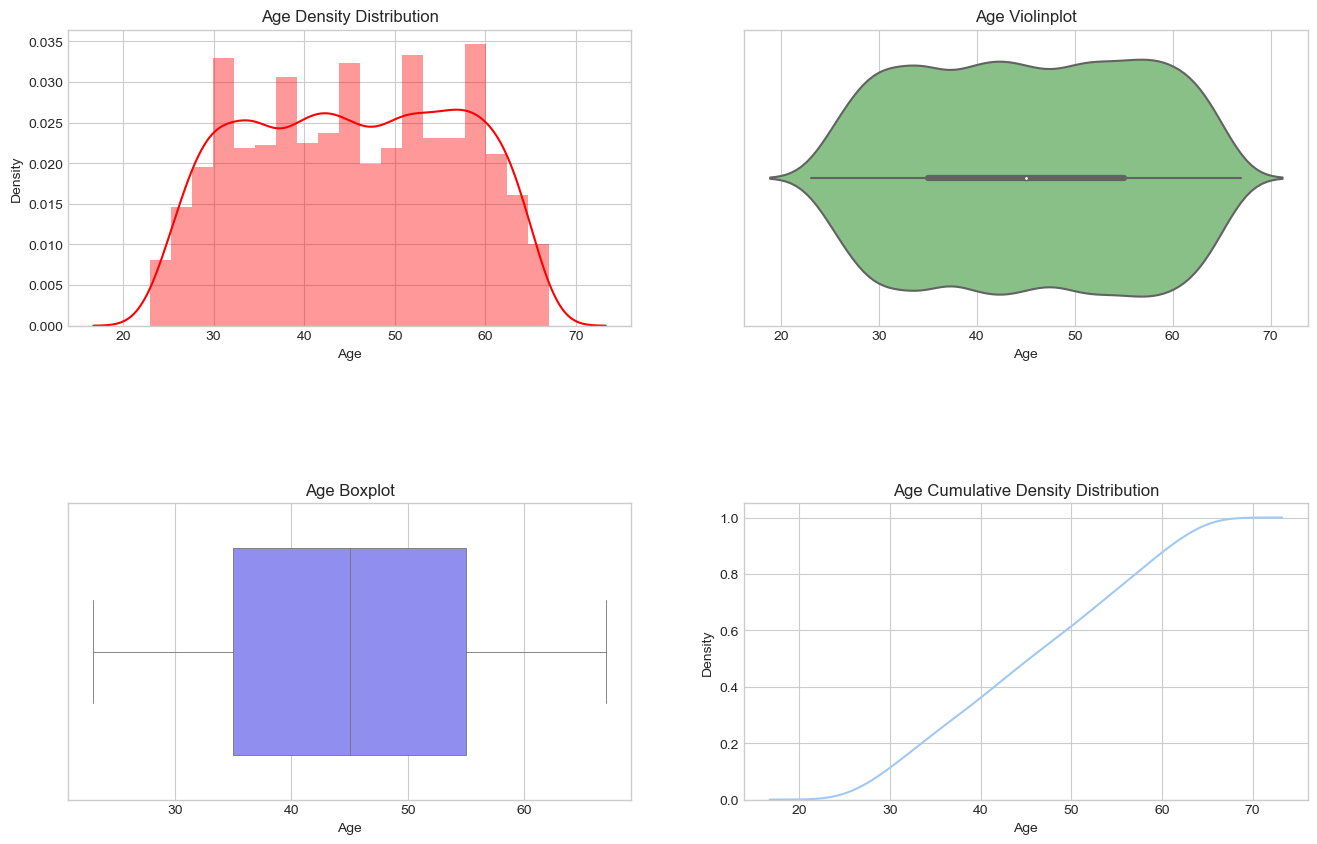

In [22]:
summary('Age')

5 Point Summary of Experience Attribute:
Experience(min) : -3
Q1                    : 10.0
Q2(Median)            : 20.0
Q3                    : 30.0
Experience(max) : 43


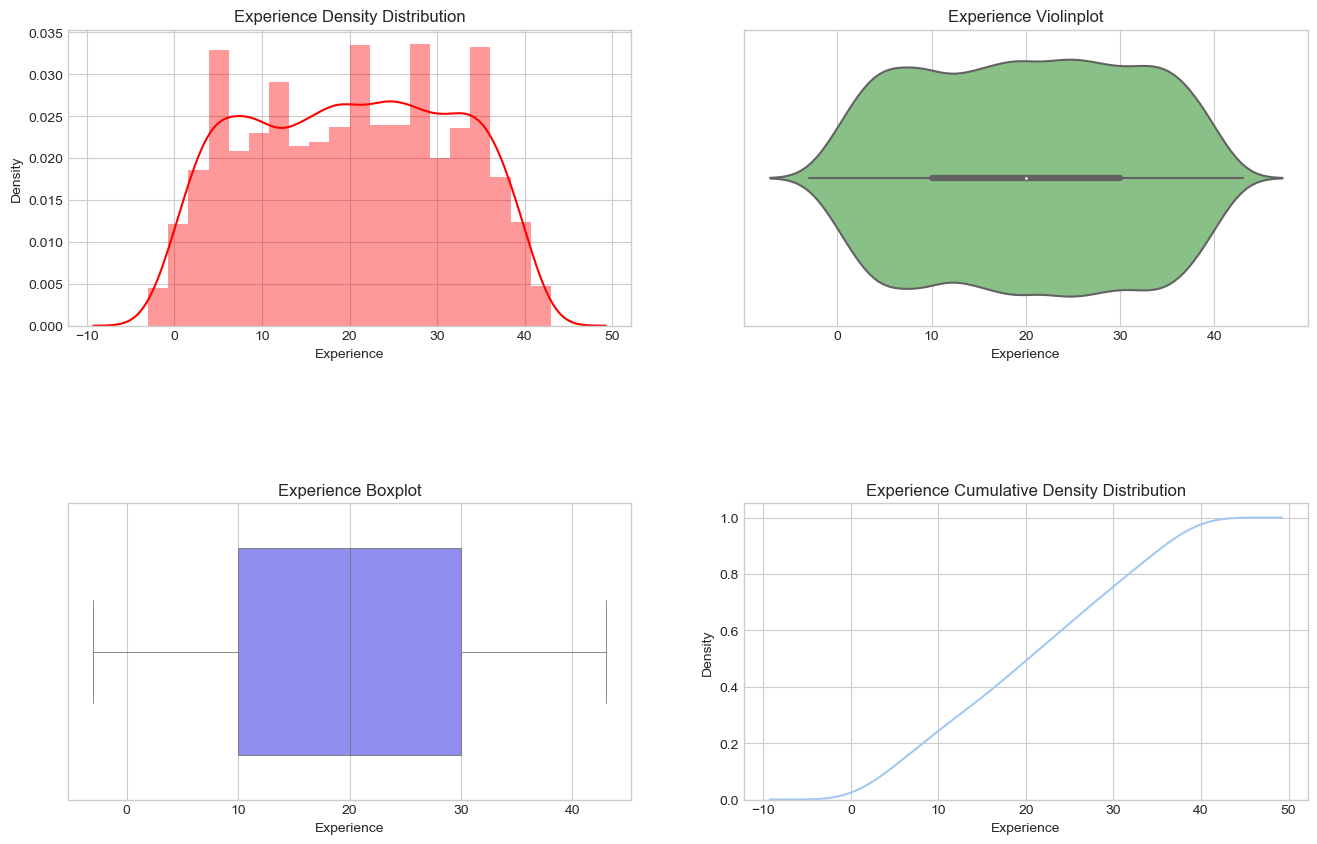

In [23]:
summary('Experience')

5 Point Summary of Income Attribute:
Income(min) : 8
Q1                    : 39.0
Q2(Median)            : 64.0
Q3                    : 98.0
Income(max) : 224


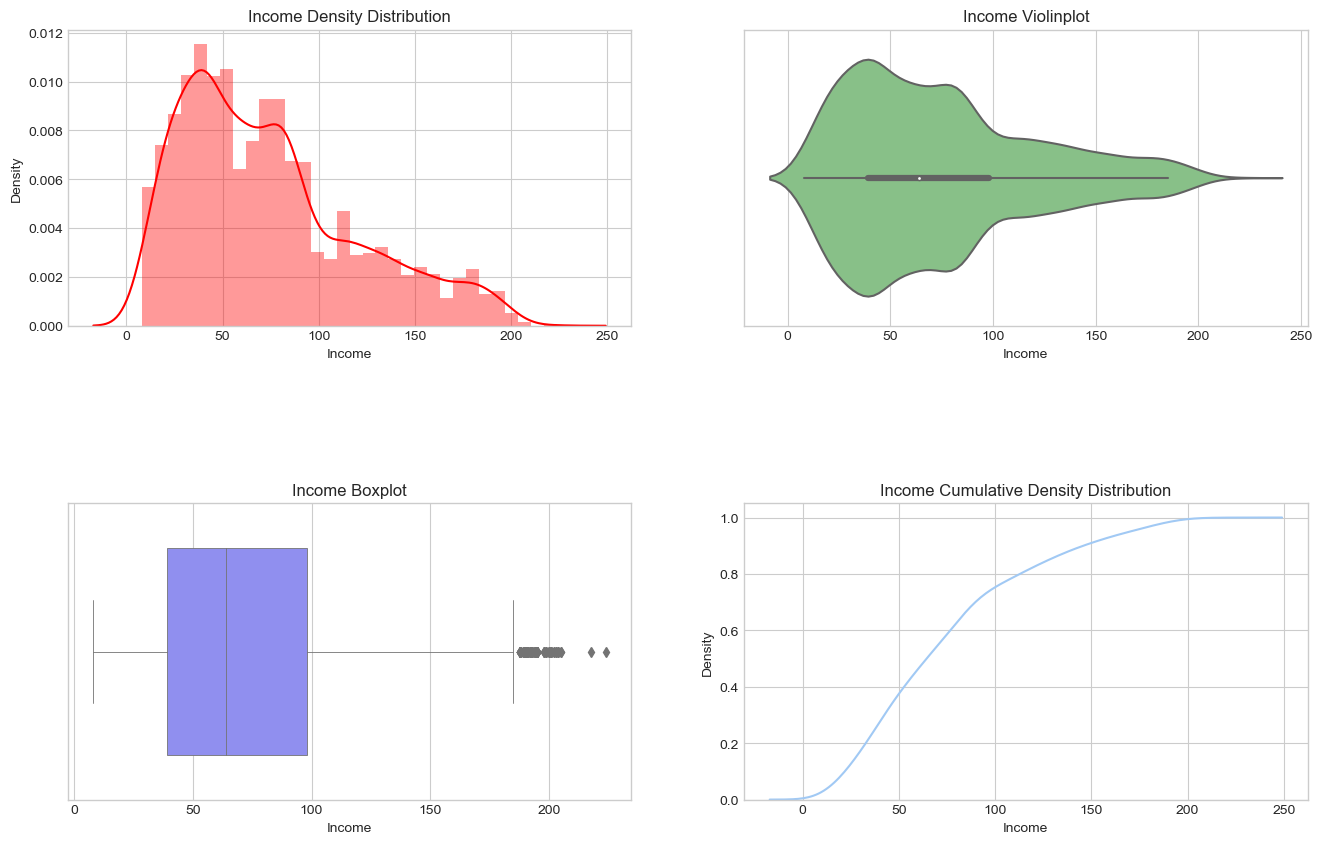

In [24]:
summary('Income')

5 Point Summary of Ccavg Attribute:
Ccavg(min) : 0.0
Q1                    : 0.7
Q2(Median)            : 1.5
Q3                    : 2.5
Ccavg(max) : 10.0


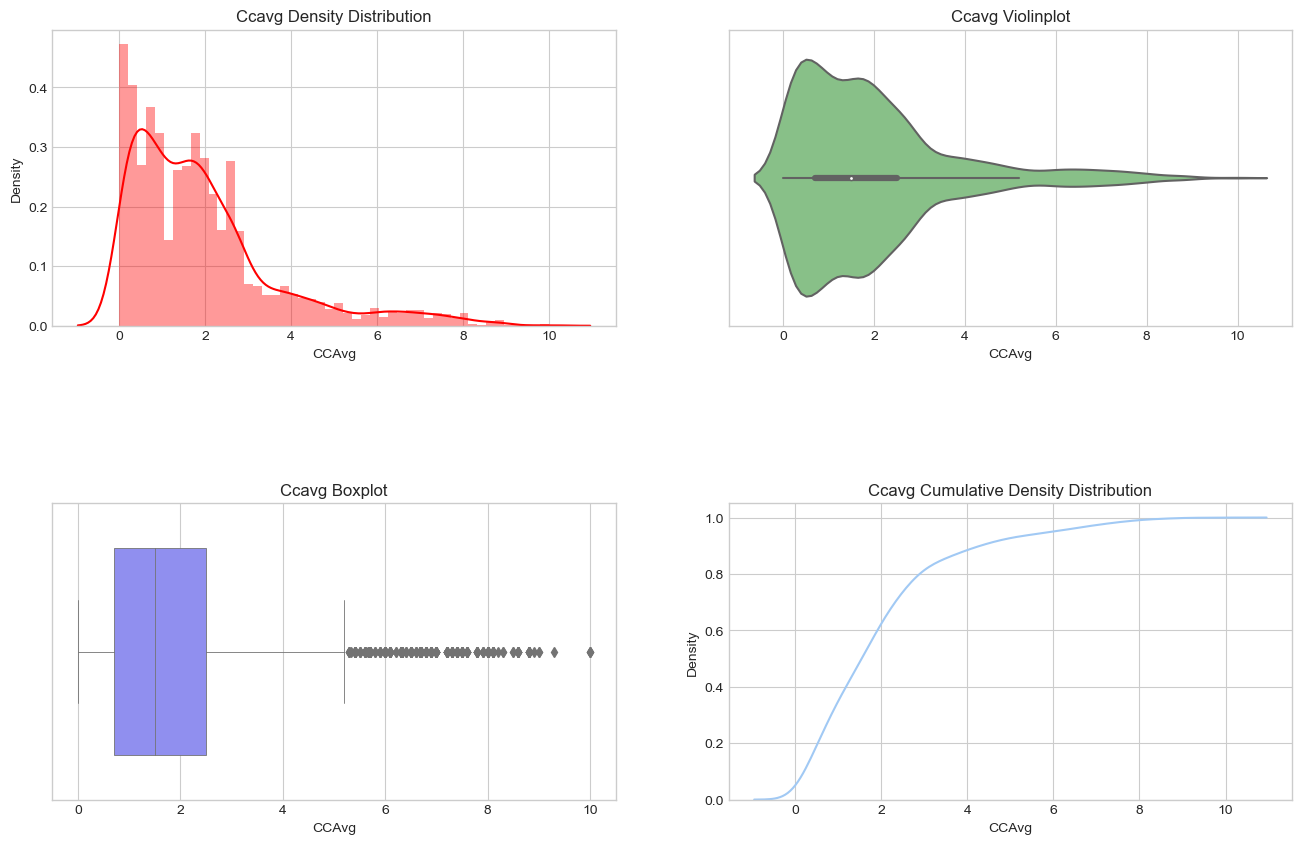

In [25]:
summary('CCAvg')

5 Point Summary of Mortgage Attribute:
Mortgage(min) : 0
Q1                    : 0.0
Q2(Median)            : 0.0
Q3                    : 101.0
Mortgage(max) : 635


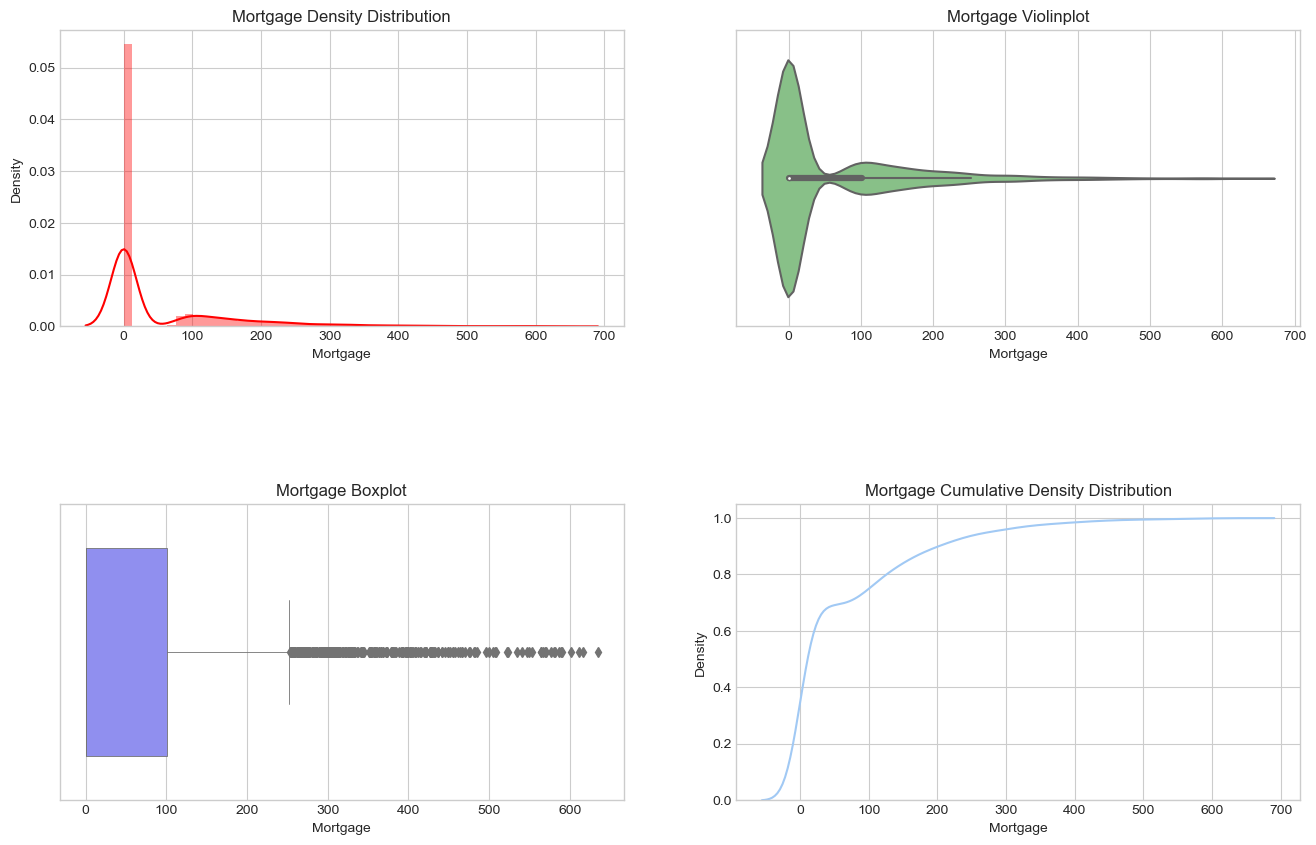

In [26]:
summary('Mortgage')

In [27]:
# Create a function that returns a Pie chart and a Bar Graph for the categorical variables:
def cat_view(x = 'Education'): #defines a comprehensive function cat_view() that generates dual visualizations
#Defines function with default parameter x='Education' for analyzing categorical columns.
    """
    Function to create a Bar chart and a Pie chart for categorical variables.
    """
    from matplotlib import cm
    color1 = cm.inferno(np.linspace(.4, .8, 30))
    color2 = cm.viridis(np.linspace(.4, .8, 30))
#Imports matplotlib colormaps; creates gradient color arrays using inferno (warm) and viridis (cool) palettes.
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
#Creates figure with 1 row, 2 columns subplots (16x6 inches) for side-by-side pie and bar charts
     
    """
    Draw a Pie Chart on first subplot.
    """    
    s = data.groupby(x).size()

    mydata_values = s.values.tolist()
    mydata_index = s.index.tolist()
#Groups data by category x, counts occurrences, extracts values and category labels.
    def func(pct, allvals):
        absolute = int(pct/100.*np.sum(allvals))
        return "{:.1f}%\n({:d})".format(pct, absolute)

#Custom function formats pie slice labels showing both percentage and absolute counts
    wedges, texts, autotexts = ax[0].pie(mydata_values, autopct=lambda pct: func(pct, mydata_values),
                                      textprops=dict(color="w"))
#Creates pie chart on first subplot with white text labels showing % and counts.
    ax[0].legend(wedges, mydata_index,
              title="Index",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1))

    plt.setp(autotexts, size=12, weight="bold")

    ax[0].set_title(f'{x.capitalize()} Piechart')
#Adds external legend, boldens text, sets title for pie chart.
    """
    Draw a Bar Graph on second subplot.
    """
    
    df = pd.pivot_table(data, index = [x], columns = ['Personal Loan'], values = ['Income'], aggfunc = len)
#Creates pivot table counting rows by categorical variable x vs target 'Personal Loan' (0=No, 1=Yes).
    labels = df.index.tolist()
    loan_no = df.values[:, 0].tolist()
    loan_yes = df.values[:, 1].tolist()
#Extracts labels, counts for No/Yes loans, creates x-positions and bar width for grouped bars.
    l = np.arange(len(labels))  # the label locations
    width = 0.35  # the width of the bars

    rects1 = ax[1].bar(l - width/2, loan_no, width, label='No Loan', color = color1)
    rects2 = ax[1].bar(l + width/2, loan_yes, width, label='Loan', color = color2)
#Plots side-by-side bars offset by width/2, using predefined color gradients.
    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax[1].set_ylabel('Scores')
    ax[1].set_title(f'{x.capitalize()} Bar Graph')
    ax[1].set_xticks(l)
    ax[1].set_xticklabels(labels)
    ax[1].legend()
#Sets labels, title, x-ticks with category names, adds legend.
    def autolabel(rects):
        
        """Attach a text label above each bar in *rects*, displaying its height."""
        
        for rect in rects:
            height = rect.get_height()
            ax[1].annotate('{}'.format(height),
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        fontsize = 'large',   
                        ha='center', va='bottom')
#Helper function adds value labels above each bar with precise positioning.
    autolabel(rects1)
    autolabel(rects2)
    fig.tight_layout()
    plt.show()
#Applies labels to both bar groups, adjusts subplot spacing, displays final visualization.

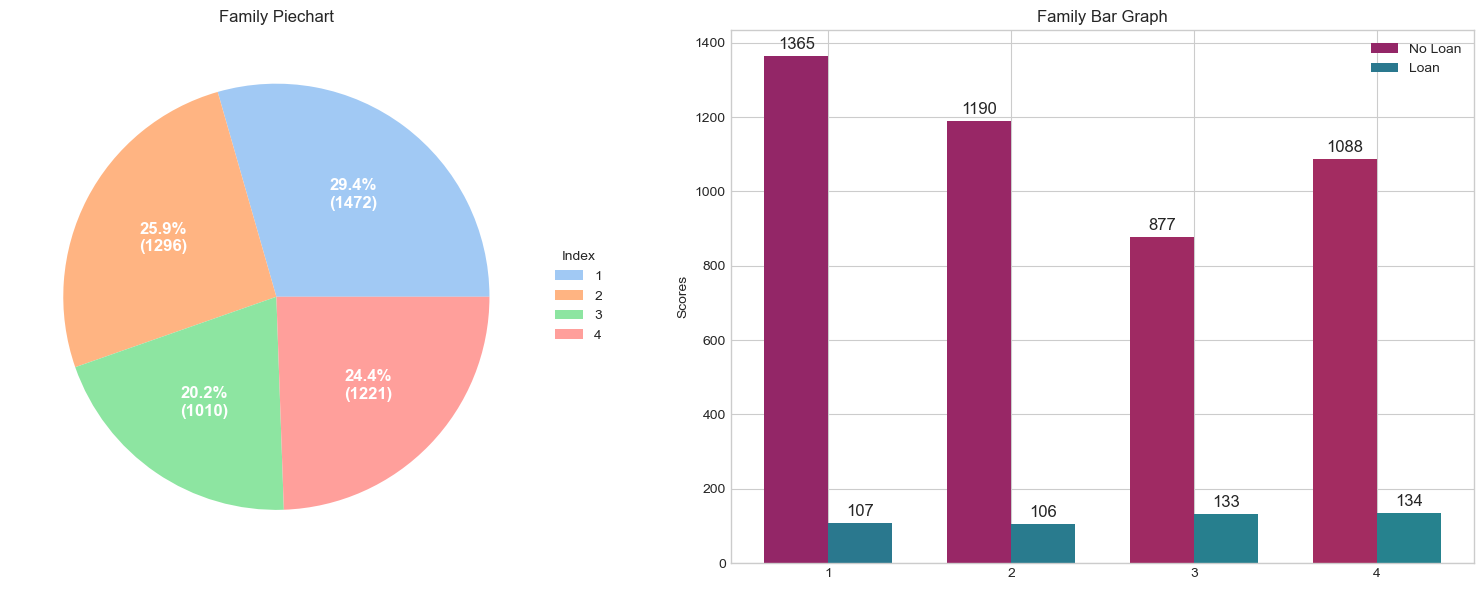

In [28]:
cat_view('Family')

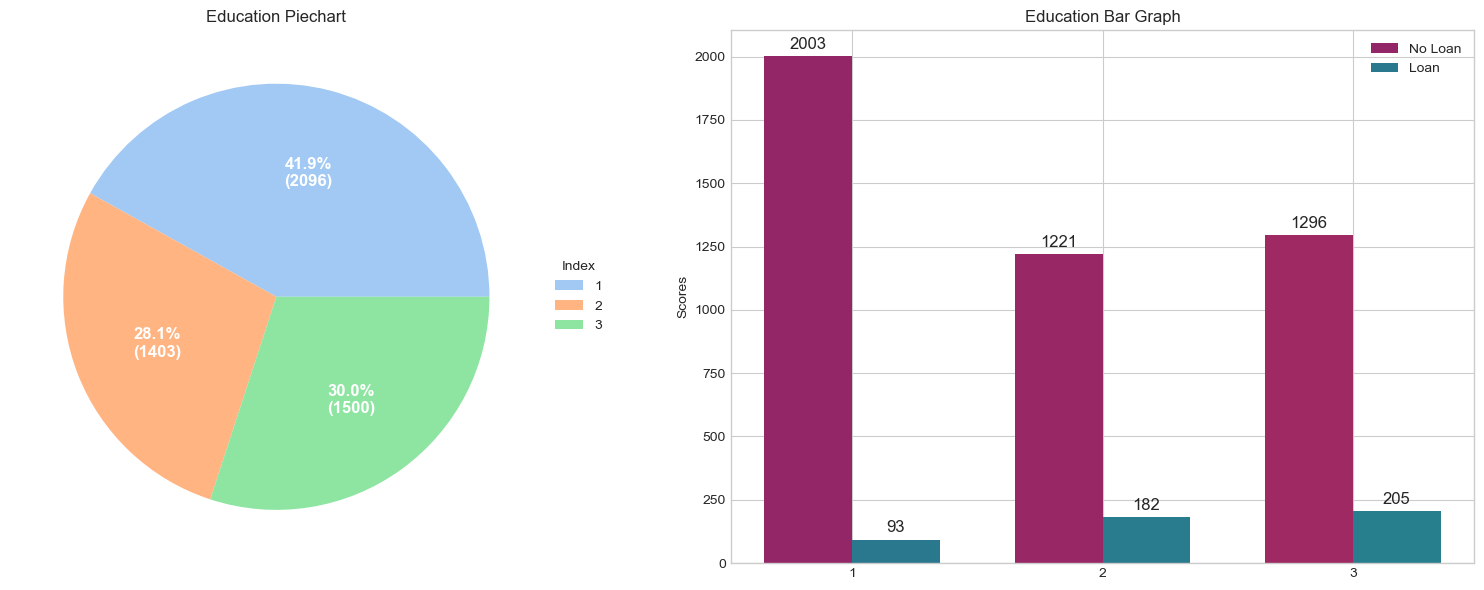

In [29]:
cat_view('Education')

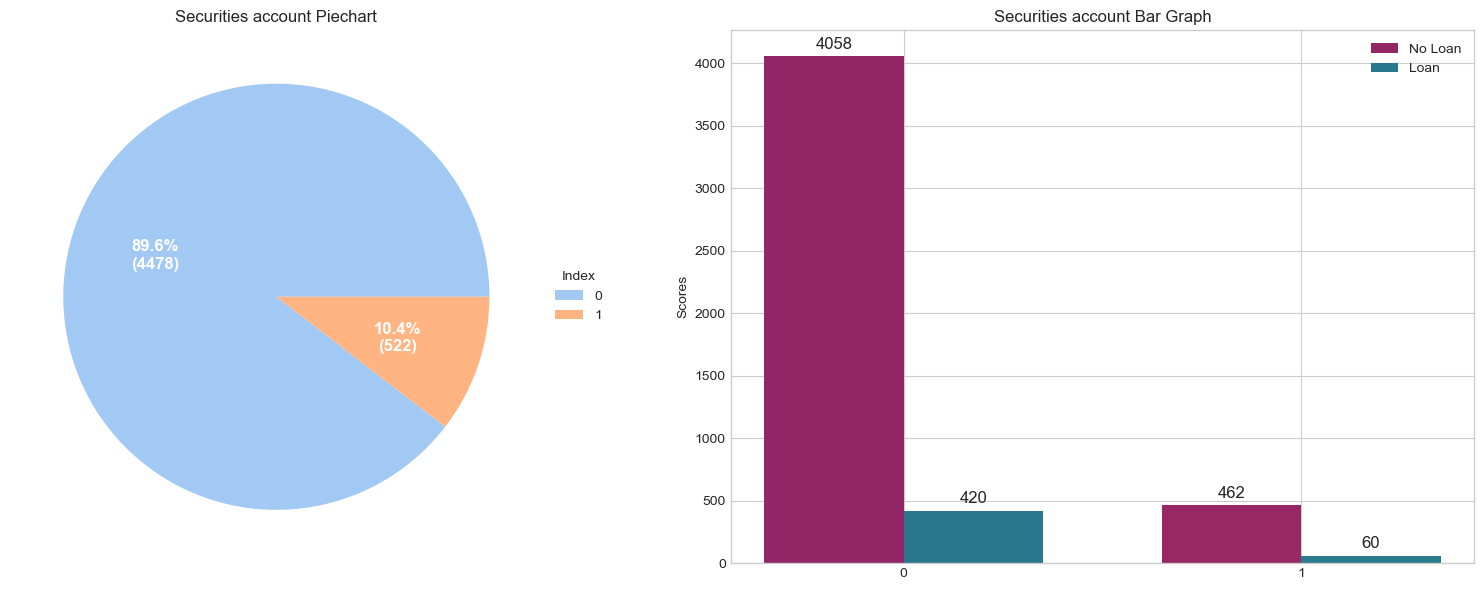

In [30]:
cat_view('Securities Account')

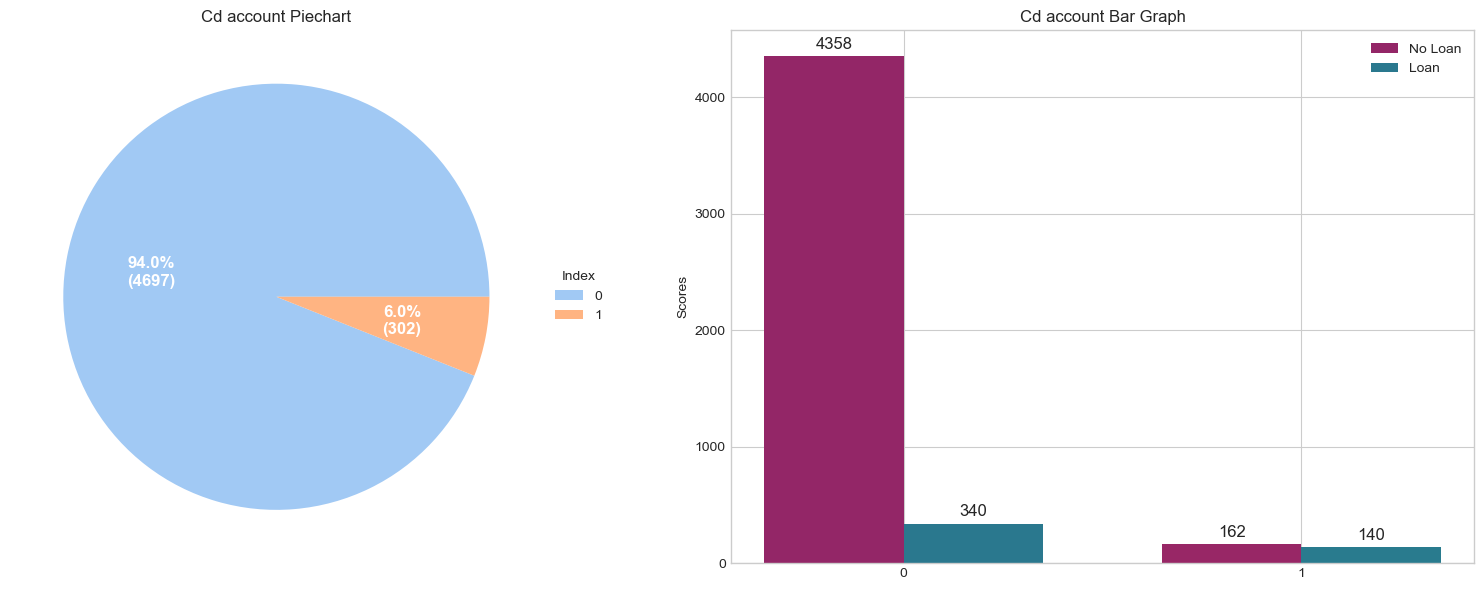

In [31]:
cat_view('CD Account')

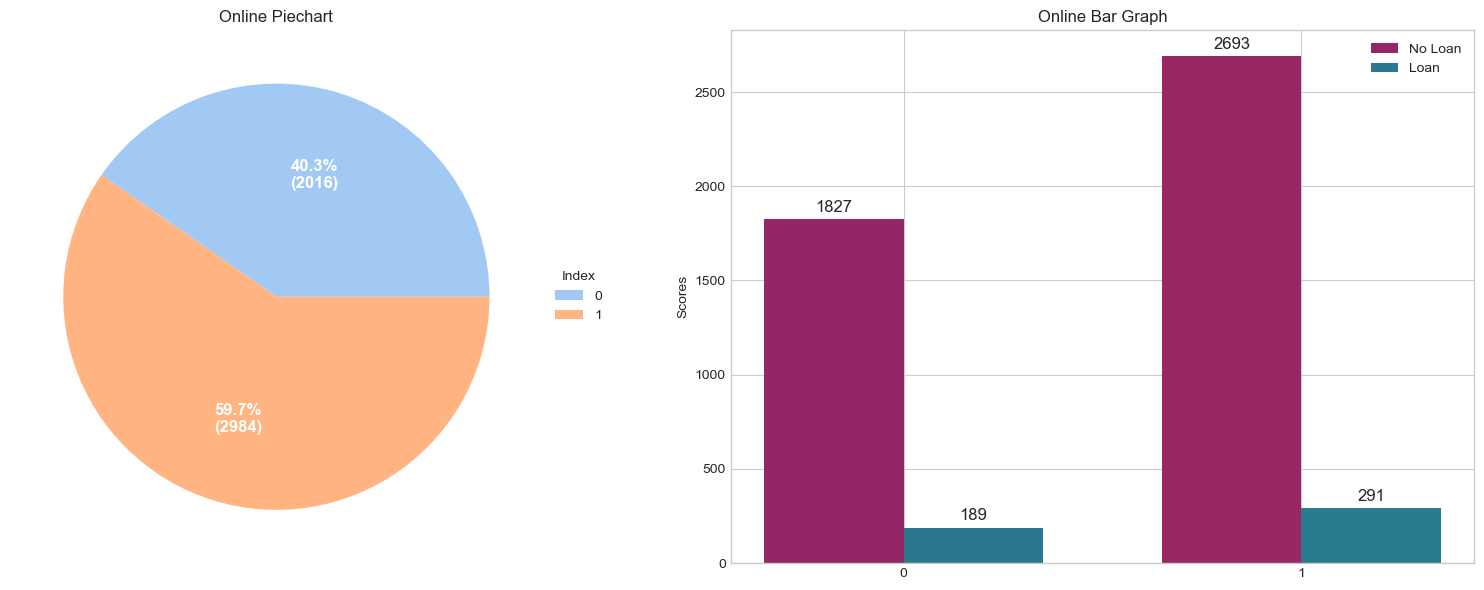

In [32]:
cat_view('Online')

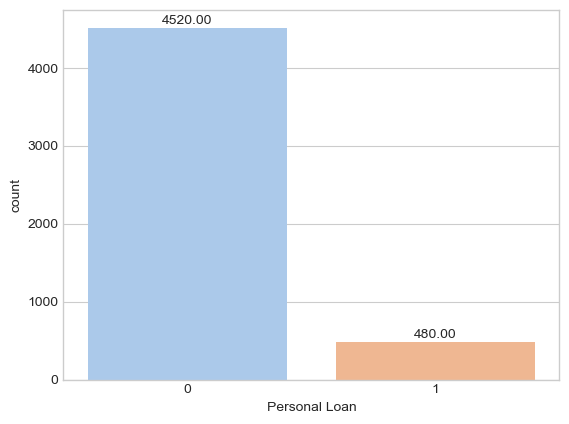

In [33]:
splot = sns.countplot(x = 'Personal Loan', data = data)
#Seaborn's countplot generates a bar plot showing the frequency counts of unique values in the 'Personal Loan' column from the DataFrame data
for p in splot.patches:
#p provides access to bar properties like height, x-position, and width for positioning labels precisely
    splot.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 5), textcoords = 'offset points')
#annotate method adds formatted text (bar height to 2 decimal places via format) at the bar's center: x-position is p.get_x() + p.get_width() / 2. (horizontal center), y-position is p.get_height() (top of bar). ha='center' and va='center' center the text; xytext=(0, 5) offsets it 5 points above, using textcoords='offset points' for relative positioning.

In [34]:
X = data.drop('Personal Loan', axis = 1) #drop() method removes the 'Personal Loan' column from data
#no inplace=True is used.
Y = data[['Personal Loan']] #select the 'Personal Loan' column from data and return it as a DataFrame

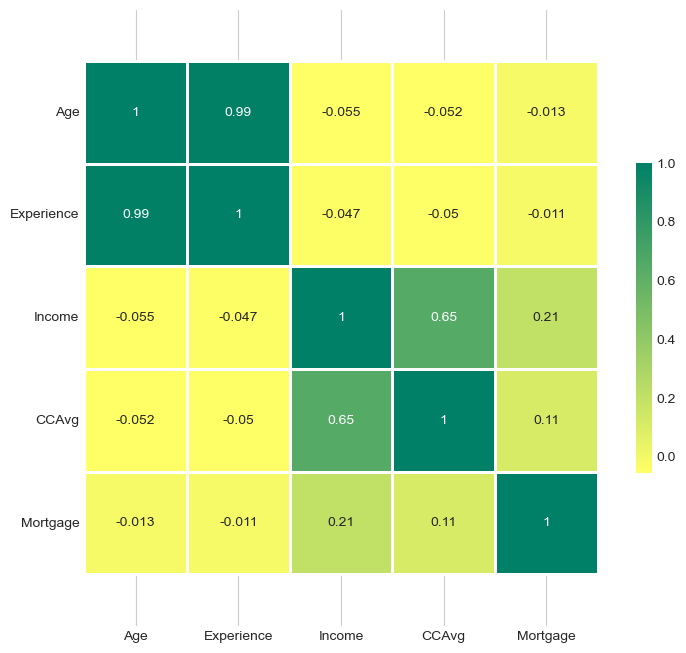

In [35]:
corr = X.corr() #corr() method calculates pairwise Pearson correlation coefficients between all numerical columns in DataFrame X
plt.figure(figsize=(10, 8)) #Creates a new matplotlib figure with dimensions 10 inches wide by 8 inches tall,
g = sns.heatmap(corr, annot=True, cmap = 'summer_r', square=True, linewidth=1, cbar_kws={'fraction' : 0.02})
#Seaborn's heatmap() visualizes the correlation matrix with annot=True displaying numerical values in each cell, cmap='summer_r' using a reversed summer colormap (cool colors for negative, warm for positive correlations), square=True forcing square cells, linewidth=1 adding white grid lines between cells, and cbar_kws={'fraction': 0.02} shrinking the colorbar width
g.set_yticklabels(g.get_yticklabels(), rotation=0, horizontalalignment='right')
#Retrieves current y-axis (feature name) labels and rotates them to 0 degrees (horizontal) with right alignment
bottom, top = g.get_ylim()
g.set_ylim(bottom + 0.5, top - 0.5)
#Gets current y-axis limits, then adjusts them by adding 0.5 to the bottom and subtracting 0.5 from the top, centering labels perfectly within square cells and preventing partial label cutoff.
plt.show()

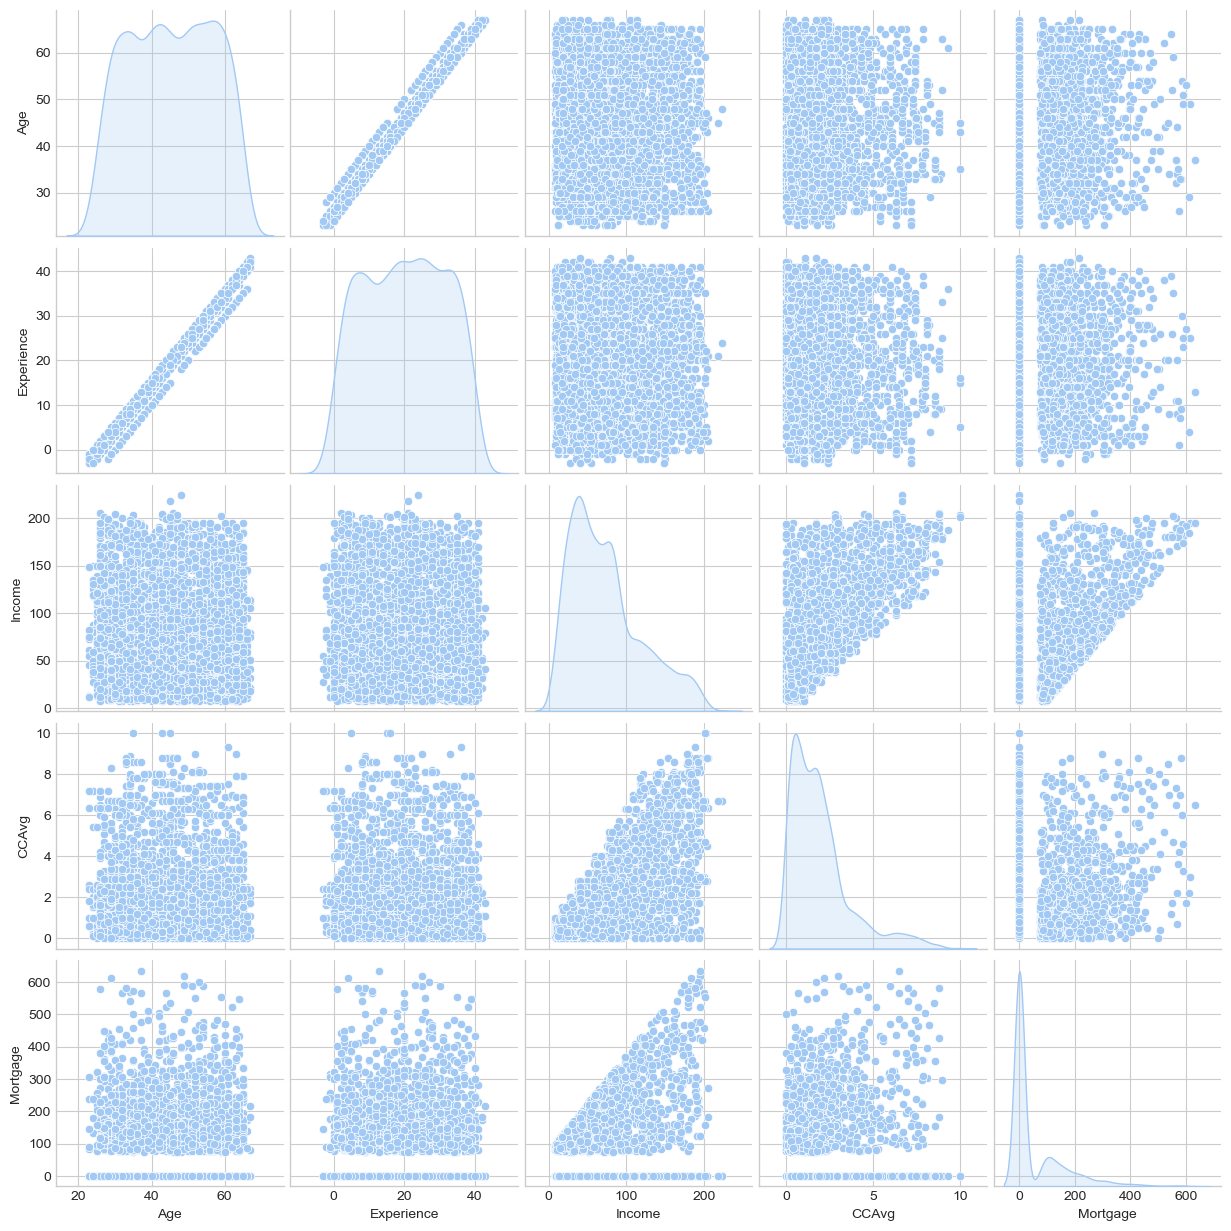

In [36]:
# Let's plot all Dependent variables to see their inter-relations.
sns.pairplot(X, diag_kind = 'kde', vars = list(data_num.columns))

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=1, stratify = Y)

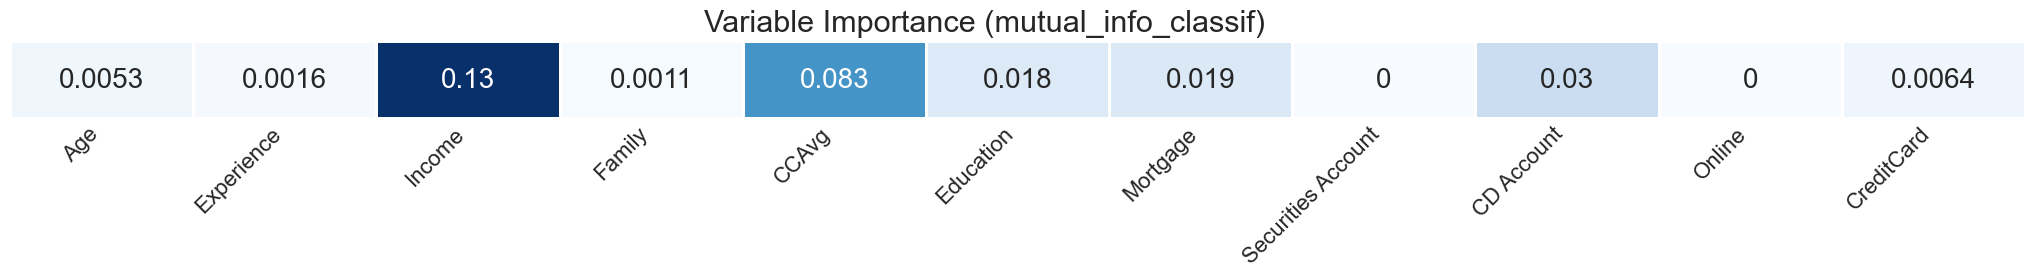

In [39]:
from sklearn.feature_selection import mutual_info_classif
#Imports the mutual_info_classif function from scikit-learn's feature selection module, which estimates mutual information between each feature in X_train and binary target y_train to measure non-linear dependency.
mutual_information = mutual_info_classif(X_train, y_train, n_neighbors=5, copy = True)
#Computes mutual information for each feature using k-nearest neighbors (k=5) for density estimation, returning a 1D array of scores where higher values indicate stronger predictive relationship with the target; copy=True creates an internal copy of input data.
plt.subplots(1, figsize=(26, 1))
#Creates a matplotlib figure with 1 row of subplots and dimensions 26 inches wide by 1 inch tall
sns.heatmap(mutual_information[:, np.newaxis].T, cmap='Blues', cbar=False, linewidths=1, annot=True, annot_kws={"size": 20})
#Reshapes 1D mutual information array into 2D matrix ([:, np.newaxis].T) for heatmap display, using blue colormap (cmap='Blues') without colorbar (cbar=False), 1-point cell borders, numerical annotations enlarged to 20pt font for readability.
plt.yticks([], [])
#Hides all y-axis ticks and labels 
plt.gca().set_xticklabels(X_train.columns, rotation=45, ha='right', fontsize=16)
#Sets x-axis tick labels to feature names from X_train.columns, rotated 45° right-aligned at 16pt font size for clear identification of each feature's importance score.
plt.suptitle("Variable Importance (mutual_info_classif)", fontsize=22, y=1.2)
#Adds a large 22pt title above the plot with y=1.2 positioning it with extra vertical space above the thin heatmap
plt.gcf().subplots_adjust(wspace=0.2)#Fine-tunes spacing between subplots (sets horizontal whitespace to 20%) on the current figure,

Text(0.5, 0, 'Relative Importance')

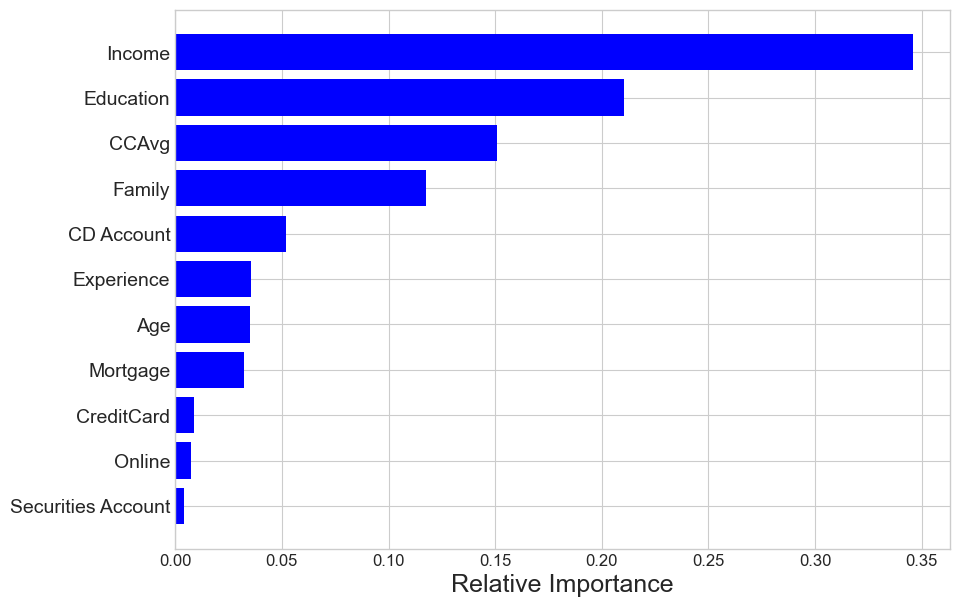

In [40]:
from sklearn.ensemble import RandomForestClassifier
#Imports the Random Forest Classifier from scikit-learn's ensemble module,
rf_clf = RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)
#Creates a Random Forest instance with 500 trees (n_estimators=500), parallel processing on all CPU scores (n_jobs=-1), and fixed randomness (random_state=42) for reproducible results.
rf_clf.fit(X_train, y_train)
#Fits the Random Forest model to training features X_train and target y_train,
features = list(X_train.columns)
importances = rf_clf.feature_importances_
#Extracts normalized feature importance scores (sum to 1.0) where higher values indicate features contributing more to reducing prediction error across the forest.
indices = np.argsort(importances)
#Creates array of indices sorted by increasing importance scores, enabling bottom-to-top ranking in the horizontal bar chart (least to most important).
fig, ax = plt.subplots(figsize=(10, 7))
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
#Draws horizontal bars where y-positions are range(len(indices)) (0 to n_features-1), heights are sorted importance scores, using blue color with center alignment.
ax.tick_params(axis="x", labelsize=12)
#x-axis tick label font size to 12pt for read importance values
ax.tick_params(axis="y", labelsize=14)
#y-axis tick label font size to 14pt for clear feature names
plt.yticks(range(len(indices)), [features[i] for i in indices])
#Assigns sorted feature names to y-axis ticks,
plt.xlabel('Relative Importance', fontsize = 18)
#Labels the x-axis "Relative Importance" with 18pt font size

In [41]:
from sklearn.preprocessing import StandardScaler #StandardScaler for numerical standardization
from sklearn.preprocessing import OneHotEncoder #OneHotEncoder for categorical encoding
from sklearn.compose import ColumnTransformer #applying different transformations to different column types.

X_train_num = X_train.select_dtypes(include='number')
#extracts all numerical columns (int, float) into X_train_num
X_train_cat = X_train.select_dtypes(include='category')
#extracts all categorical columns into X_train_cat
num_attribs = list(X_train_num.columns)
cat_attribs = list(X_train_cat.columns)
#Converts column names from numerical and categorical subsets to Python lists for use in ColumnTransformer specification.
transformer = ColumnTransformer([
        ("num", StandardScaler(), num_attribs),
        ("cat", OneHotEncoder(), cat_attribs),
    ])
#Creates a transformer pipeline with two steps: "num" applies StandardScaler() (mean=0, std=1) to numerical columns, "cat" applies OneHotEncoder() (dummy variables) to categorical columns
X_train = transformer.fit_transform(X_train)
print(X_train.shape)
X_train[1, :]#displays the complete feature vector for the second sample

(4000, 20)


array([ 1.54242379,  1.64860495, -1.09229452, -0.93991736, -0.55912257,
        0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.        ,  1.        ,  0.        ,  1.        ,
        0.        ,  1.        ,  0.        ,  1.        ,  0.        ])

In [42]:
y_train = np.array(y_train)
print(y_train.shape)

(4000, 1)


In [43]:
def train_model(model):
    m = model[1]
    y_train_pred = cross_val_predict(model[1], X_train, y_train, cv=5)
#Uses 5-fold stratified cross-validation to generate out-of-sample predictions for every sample in X_train
#each fold trains on 4/5 data and predicts the held-out 1/5,
    cm = confusion_matrix(y_train, y_train_pred)
    print('Confusion matrix: ' + model[0])
    print(cm)
    print()
    accuracy = accuracy_score(y_train, y_train_pred)
    precision = precision_score(y_train, y_train_pred)
    recall = recall_score(y_train, y_train_pred)
    f1 = f1_score(y_train, y_train_pred)
    print(f'{model[0]} Accuracy: {accuracy}')
    print(f'{model[0]} Precision: {precision}')
    print(f'{model[0]} Recall: {recall}')
#harmonic mean of precision and recall: 2 × (precision × recall) / (precision + recall).
    print(f'{model[0]} f1 - score: {f1}')

In [44]:
train_model(('Gaussian Naive Bayes', GaussianNB()))

Confusion matrix: Gaussian Naive Bayes
[[3411  205]
 [ 188  196]]

Gaussian Naive Bayes Accuracy: 0.90175
Gaussian Naive Bayes Precision: 0.48877805486284287
Gaussian Naive Bayes Recall: 0.5104166666666666
Gaussian Naive Bayes f1 - score: 0.49936305732484076


In [45]:
train_model(('Logistic Regression', LogisticRegression(solver="liblinear")))

Confusion matrix: Logistic Regression
[[3578   38]
 [ 124  260]]

Logistic Regression Accuracy: 0.9595
Logistic Regression Precision: 0.87248322147651
Logistic Regression Recall: 0.6770833333333334
Logistic Regression f1 - score: 0.7624633431085044


In [46]:
train_model(('k Nearest Neighbor', KNeighborsClassifier(n_neighbors= 7, weights = 'distance' )))

Confusion matrix: k Nearest Neighbor
[[3611    5]
 [ 177  207]]

k Nearest Neighbor Accuracy: 0.9545
k Nearest Neighbor Precision: 0.9764150943396226
k Nearest Neighbor Recall: 0.5390625
k Nearest Neighbor f1 - score: 0.6946308724832215


In [47]:
train_model(('SVM', SVC(gamma='auto')))

Confusion matrix: SVM
[[3615    1]
 [  87  297]]

SVM Accuracy: 0.978
SVM Precision: 0.9966442953020134
SVM Recall: 0.7734375
SVM f1 - score: 0.8709677419354839


In [48]:
train_model(('CART', DecisionTreeClassifier()))

Confusion matrix: CART
[[3575   41]
 [  34  350]]

CART Accuracy: 0.98125
CART Precision: 0.8951406649616368
CART Recall: 0.9114583333333334
CART f1 - score: 0.903225806451613


In [49]:
train_model(('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)))

Confusion matrix: Random Forest
[[3608    8]
 [  46  338]]

Random Forest Accuracy: 0.9865
Random Forest Precision: 0.976878612716763
Random Forest Recall: 0.8802083333333334
Random Forest f1 - score: 0.926027397260274


In [50]:
from sklearn.model_selection import GridSearchCV
#tests all hyperparameter combinations from the parameter grid using cross-validation
param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]}
#first grid:3*4=12
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},]
#second grid=1*2*3=6
#18 unique parameter combination
forest_reg = RandomForestClassifier(random_state=42)
#Total training rounds: (12+6)*5=90 model fits
grid_search = GridSearchCV(forest_reg, param_grid, cv=5, #5-fold cross-validation per combination
                           scoring='f1',
                           return_train_score=True) #track both train and validation scores
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='f1')

In [51]:
grid_search.best_params_

{'max_features': 8, 'n_estimators': 30}

In [52]:
rf_clf = grid_search.best_estimator_ #fully trained Random Forest classifier with the optimal hyperparameters found during GridSearchCV.

In [53]:
X_test = transformer.fit_transform(X_test)
print(X_test.shape)

(1000, 20)


In [54]:
y_test = np.array(y_test)
print(y_test.shape)

(1000, 1)


In [55]:
rf_clf.fit(X_test, y_test)

RandomForestClassifier(max_features=8, n_estimators=30, random_state=42)

In [56]:
y_test_predict = rf_clf.predict(X_test)

In [57]:
rf_clf.score(X_test, y_test)

1.0

In [58]:
print(metrics.classification_report(y_test, y_test_predict, labels=[1, 0]))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        96
           0       1.00      1.00      1.00       904

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

